In [1]:
%load_ext autoreload
%autoreload 2

import os 
from pathlib import Path

# Create a dcbench-config.yaml in the repo root
repo_root = Path(".").resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

config_path = repo_root / "dcbench-config.yaml"
local_dir = repo_root / ".dcbench"

config_content = f"""local_dir: {local_dir}
public_bucket_name: dcbench
hidden_bucket_name: dcbench-hidden
celeba_dir: {local_dir / 'datasets' / 'celeba'}
imagenet_dir: {local_dir / 'datasets' / 'imagenet'}
"""

with open(config_path, "w") as f:
    f.write(config_content)

os.environ["DCBENCH_CONFIG"] = str(config_path)
import meerkat as mk

# `dcbench`: Slice Discovery Demo

This notebook showcases the interface for Slice Discovery in `dcbench`. You can read more about the task in our [documentation](https://dcbench.readthedocs.io/en/latest/tasks.html#slice-discovery) and on our [website](https://www.datacentricai.cc/benchmark/).

Let's start off by importing `dcbench` and listing the supported tasks.

In [2]:
import dcbench
dcbench.tasks

,name,summary
minidata,Minimal Data Selection,"Given a large training dataset, what is the sm..."
slice_discovery,Slice Discovery,Machine learnings models that achieve high ove...
budgetclean,Data Cleaning on a Budget,"When it comes to data preparation, data cleani..."


## Exploring problems

In this notebook, we'll focus on the [Slice Discovery](https://dcbench.readthedocs.io/en/latest/tasks.html#slice-discovery) task. 

In the `dcbench` API, each task is represented by a `dcbench.Task` object that can be accessed by *task_id* (*e.g.* `dcbench.tasks["slice_discovery"]`).

In [3]:
slice_discovery = dcbench.tasks["slice_discovery"]

Each task features a collection of *problems* (*i.e.* instances of the task). For example, the `slice_discovery` task includes dozens of problems across a number of different datasets.

We can list the problems with 

In [4]:
slice_discovery.problems["p_118660"]

SliceDiscoveryProblem(artifacts={'activations': 'DataPanelArtifact', 'base_dataset': 'VisionDatasetArtifact', 'clip': 'DataPanelArtifact', 'model': 'ModelArtifact', 'test_predictions': 'DataPanelArtifact', 'test_slices': 'DataPanelArtifact', 'val_predictions': 'DataPanelArtifact'}, attributes={'alpha': 0.01709975946676697, 'dataset': 'imagenet', 'n_pred_slices': 5, 'slice_category': 'rare', 'slice_names': ['menu.n.02'], 'target_name': 'food.n.01'})

In [5]:
problem = slice_discovery.problems["p_118660"]

In [6]:
problem.artifacts

{'activations': <dcbench.common.artifact.DataPanelArtifact at 0x7e8ef1c4d900>,
 'base_dataset': <dcbench.common.artifact.VisionDatasetArtifact at 0x7e8ef1d4e050>,
 'clip': <dcbench.common.artifact.DataPanelArtifact at 0x7e8ef1d4e0b0>,
 'model': <dcbench.common.artifact.ModelArtifact at 0x7e8ef1c4d990>,
 'test_predictions': <dcbench.common.artifact.DataPanelArtifact at 0x7e8ef1c4d9f0>,
 'test_slices': <dcbench.common.artifact.DataPanelArtifact at 0x7e8ef1c4da50>,
 'val_predictions': <dcbench.common.artifact.DataPanelArtifact at 0x7e8ef1c4dab0>}

,id (PandasSeriesColumn),image (ImageColumn),name (PandasSeriesColumn),synset (PandasSeriesColumn)
0,n01440764_10026,,"tench, Tinca tinca",n01440764
1,n01440764_10027,,"tench, Tinca tinca",n01440764
2,n01440764_10029,,"tench, Tinca tinca",n01440764
3,n01440764_10040,,"tench, Tinca tinca",n01440764
4,n01440764_10042,,"tench, Tinca tinca",n01440764
...,...,...,...,...
1331162,ILSVRC2012_val_00005961,,fountain,n03388043
1331163,ILSVRC2012_val_00008801,,"confectionery, confectionary, candy store",n03089624
1331164,ILSVRC2012_val_00008176,,"ostrich, Struthio camelus",n01518878
1331165,ILSVRC2012_val_00004764,,"paddlewheel, paddle wheel",n03874293

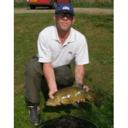
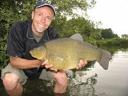
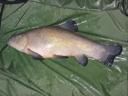
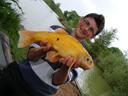
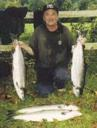
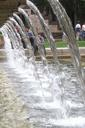
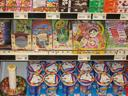
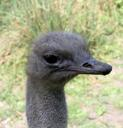
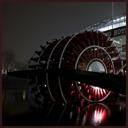
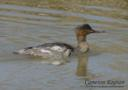

In [7]:
problem["base_dataset"]

In [10]:
from dcbench.tasks.slice_discovery import confusion_sdm, domino_sdm

ImportError: cannot import name 'confusion_sdm' from 'dcbench.tasks.slice_discovery' (/home/azureuser/dcbench/dcbench/tasks/slice_discovery/__init__.py)

In [ ]:
solution = confusion_sdm(problem)

/home/common/envs/conda/envs/dcbench/lib/python3.9/site-packages/meerkat/ml/__init__.py:7: ExperimentalWarning: The `meerkat.ml` module is experimental and has limited test coverage. Proceed with caution.
  warnings.warn(


In [ ]:
problem.evaluate(solution)

{'precision_at_10': 0.3, 'precision_at_25': 0.4, 'auroc': 0.9485750209555742}

In [ ]:
import numpy as np
#np.random.seed(128)
problem.n_pred_slices = 10

solution = domino_sdm(problem)

 33%|███▎      | 33/100 [00:01<00:02, 22.46it/s]


In [ ]:
problem.evaluate(solution)

{'precision_at_10': 1.0, 'precision_at_25': 0.84, 'auroc': 0.993880972338642}

In [ ]:
dp = mk.merge(problem["test_slices"], problem["test_predictions"], on="id")
dp = mk.merge(problem["base_dataset"], dp, on="id") 

In [ ]:
from sklearn.metrics import recall_score
recall_score(dp["target"].data, dp["probs"][:, 1] > 0.5)

0.892426273458445

In [ ]:
mask = (dp["slices"] == 1).data.squeeze()
recall_score(dp.lz[mask]["target"].data, dp.lz[mask]["probs"][:, 1] > 0.5)

0.421875

In [ ]:
dp.lz[((dp["target"] == 1) & (dp["probs"][:, 1] < 0.5).data.numpy()).astype(bool)]["name"].data.value_counts()

ice lolly, lolly, lollipop, popsicle    45
cup                                     40
red wine                                40
hay                                     37
menu                                    34
dough                                   18
eggnog                                  14
pretzel                                 12
hot pot, hotpot                         10
chocolate sauce, chocolate syrup         9
ice cream, icecream                      8
meat loaf, meatloaf                      7
burrito                                  7
espresso                                 7
guacamole                                6
plate                                    5
trifle                                   5
French loaf                              4
bagel, beigel                            3
pizza, pizza pie                         3
mashed potato                            2
cheeseburger                             1
hotdog, hot dog, red hot                 1
carbonara  

,id (PandasSeriesColumn),pred_slices (NumpyArrayColumn),index (PandasSeriesColumn),image (ImageColumn),name (PandasSeriesColumn),synset (PandasSeriesColumn)
0,n07802026_2233,"np.ndarray(shape=(10,))",3370,,hay,n07802026
1,n07802026_19687,"np.ndarray(shape=(10,))",5897,,hay,n07802026
2,n07802026_7846,"np.ndarray(shape=(10,))",3937,,hay,n07802026
3,n07802026_20956,"np.ndarray(shape=(10,))",5891,,hay,n07802026
4,n07802026_12444,"np.ndarray(shape=(10,))",1592,,hay,n07802026
5,n07802026_9576,"np.ndarray(shape=(10,))",3985,,hay,n07802026
6,n07802026_18815,"np.ndarray(shape=(10,))",1365,,hay,n07802026
7,n07802026_18147,"np.ndarray(shape=(10,))",641,,hay,n07802026
8,n07802026_8104,"np.ndarray(shape=(10,))",2976,,hay,n07802026
9,n07802026_5992,"np.ndarray(shape=(10,))",3105,,hay,n07802026

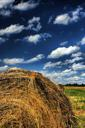
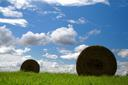
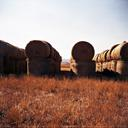
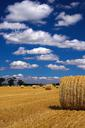
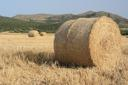
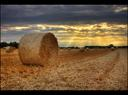
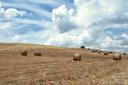
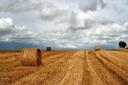
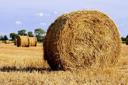
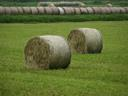

In [ ]:
import meerkat as mk
dp = mk.merge(solution["pred_slices"], problem["base_dataset"], on="id")
dp.lz[(-dp["pred_slices"][:,7]).argsort()[:10]]

In [ ]:
problem.attributes

{'alpha': 0.01709975946676697,
 'dataset': 'imagenet',
 'n_pred_slices': 5,
 'slice_category': 'rare',
 'slice_names': ['hay.n.01'],
 'target_name': 'food.n.01'}

In [ ]:
type(problem.attributes["slice_names"])

list